# 11 — Comparison of All Methods

This notebook does **no** computing. It holds the results the other notebooks produced, puts them
side by side, and draws the charts.

Every number below was printed by one of the notebooks listed in the table. Nothing is loaded from
disk, nothing is saved, and no algorithm runs here. That keeps the comparison quick to open and
impossible to break.

| Where the numbers come from | Notebook |
|---|---|
| Leave everything alone | `03_baseline` |
| Greedy 2A and 2B, rejection reasons, sensitivity | `04_greedy` |
| Exact MILP, model size, timing | `05_classical` |
| Small-instance quantum validation | `06_Nestle_DOM_Quantum_Investigation_executed` |
| Slack-free QUBO encoding | `07_Nestle_DOM_Quantum_Method2_executed` |
| Batched quantum run | `09_Nestle_DOM_Scaled_Quantum_Detailed_executed` |
| QAOA on real data | `10_DOM_QAOA_vs_Greedy_RealData_executed` |
| Hybrid QAOA restricted master | `11_Nestle_DOM_Hybrid_Quantum_RMP` |

## 1. Setup

Only pandas and matplotlib. No data files.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print("ready")

ready


## 2. The classical results

All four rows are measured on the same 472 focus orders, with the same objective and the same rule
checks.

In [2]:
CLASSICAL = pd.DataFrame([
    dict(method="Leave everything alone", objective=44_365_993.78, fill=90.47, moves=0,
         penalty=84_749, freight=565_479, runtime=0.21),
    dict(method="Greedy 2A - by order value", objective=44_810_603.97, fill=91.28, moves=41,
         penalty=75_259, freight=638_165, runtime=0.40),
    dict(method="Greedy 2B - by shortage", objective=44_786_479.00, fill=91.26, moves=39,
         penalty=75_429, freight=636_816, runtime=0.42),
    dict(method="Exact MILP (PuLP + CBC)", objective=46_295_828.48, fill=93.28, moves=66,
         penalty=32_333, freight=622_880, runtime=63.72),
])

show = CLASSICAL.copy()
for c in ["objective", "penalty", "freight"]:
    show[c] = show[c].map(lambda v: f"{v:,.0f}")
show["fill"] = CLASSICAL["fill"].map(lambda v: f"{v:.2f}%")
show["runtime"] = CLASSICAL["runtime"].map(lambda v: f"{v:.2f}s")
print(show.to_string(index=False))

                    method  objective   fill  moves penalty freight runtime
    Leave everything alone 44,365,994 90.47%      0  84,749 565,479   0.21s
Greedy 2A - by order value 44,810,604 91.28%     41  75,259 638,165   0.40s
   Greedy 2B - by shortage 44,786,479 91.26%     39  75,429 636,816   0.42s
   Exact MILP (PuLP + CBC) 46,295,828 93.28%     66  32,333 622,880  63.72s


### 2.1 Compared with leaving everything alone

In [3]:
b = CLASSICAL.iloc[0]
D = pd.DataFrame({
    "method"                 : CLASSICAL["method"],
    "change in objective ($)": CLASSICAL["objective"] - b["objective"],
    "change in fill (points)": CLASSICAL["fill"] - b["fill"],
    "change in penalty ($)"  : CLASSICAL["penalty"] - b["penalty"],
    "change in freight ($)"  : CLASSICAL["freight"] - b["freight"],
    "orders moved"           : CLASSICAL["moves"],
}).set_index("method").round(2)
print(D.to_string())

print()
print("The solver moves 66 orders against the greedy's 41, and still pays")
print(f"${(CLASSICAL.freight[1] - CLASSICAL.freight[3]):,.0f} less in extra freight.")
print("Planning all orders together lets it pick cheaper lanes and connect moves.")

                            change in objective ($)  change in fill (points)  change in penalty ($)  change in freight ($)  orders moved
method                                                                                                                                  
Leave everything alone                         0.00                     0.00                      0                      0             0
Greedy 2A - by order value                444610.19                     0.81                  -9490                  72686            41
Greedy 2B - by shortage                   420485.22                     0.79                  -9320                  71337            39
Exact MILP (PuLP + CBC)                  1929834.70                     2.81                 -52416                  57401            66

The solver moves 66 orders against the greedy's 41, and still pays
$15,285 less in extra freight.
Planning all orders together lets it pick cheaper lanes and connect moves.


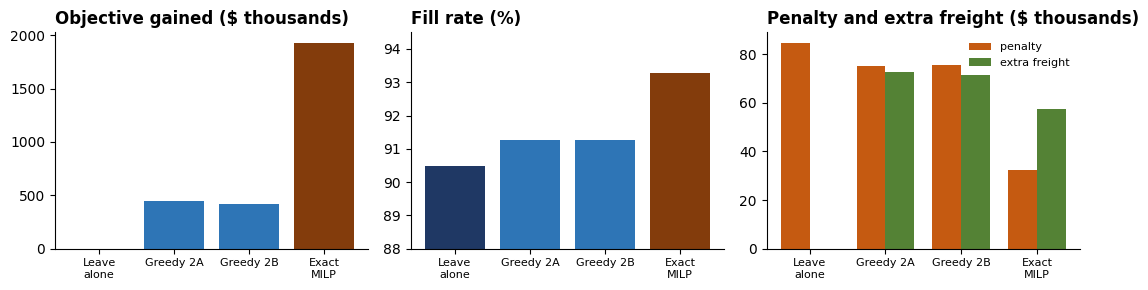

In [4]:
lab = ["Leave\nalone", "Greedy 2A", "Greedy 2B", "Exact\nMILP"]
col = ["#1f3864", "#2e75b6", "#2e75b6", "#833c0c"]
fig, ax = plt.subplots(1, 3, figsize=(11, 3))

ax[0].bar(lab, (CLASSICAL.objective - b.objective) / 1e3, color=col)
ax[0].set_title("Objective gained ($ thousands)", loc="left", fontweight="bold")
ax[1].bar(lab, CLASSICAL.fill, color=col); ax[1].set_ylim(88, 94.5)
ax[1].set_title("Fill rate (%)", loc="left", fontweight="bold")
w = 0.38; xx = np.arange(4)
ax[2].bar(xx - w/2, CLASSICAL.penalty / 1e3, w, label="penalty", color="#c55a11")
ax[2].bar(xx + w/2, (CLASSICAL.freight - b.freight) / 1e3, w, label="extra freight",
          color="#548235")
ax[2].set_xticks(xx); ax[2].set_xticklabels(lab)
ax[2].set_title("Penalty and extra freight ($ thousands)", loc="left", fontweight="bold")
ax[2].legend(fontsize=8, frameon=False)
for a in ax:
    a.spines[["top", "right"]].set_visible(False); a.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

## 3. How far the greedy is from the best answer

The MILP is exact, so its answer is the ceiling. The last column is the more useful one: it measures
the greedy against the gain that can actually be reached, not against the whole objective.

In [5]:
opt, base = 46_295_828.48, 44_365_993.78
gre = 44_810_603.97

G = pd.DataFrame([
    dict(method="Leave everything alone", objective=base,
         gap_pct=(opt - base) / opt * 100, share_of_reachable_gain=0.0),
    dict(method="Greedy 2A", objective=gre,
         gap_pct=(opt - gre) / opt * 100,
         share_of_reachable_gain=(gre - base) / (opt - base) * 100),
    dict(method="Exact MILP", objective=opt, gap_pct=0.0, share_of_reachable_gain=100.0),
]).round(3)
print(G.to_string(index=False))

                method   objective  gap_pct  share_of_reachable_gain
Leave everything alone 44365993.78    4.168                    0.000
             Greedy 2A 44810603.97    3.208                   23.039
            Exact MILP 46295828.48    0.000                  100.000


## 4. How the exact model scales

Five sizes of the same problem, each solved to the proven best answer. The greedy figure at each size
comes from re-running the greedy on that same subset.

In [6]:
SWEEP = pd.DataFrame([
    dict(orders=50,  binaries=227,  rows=35_830,  wall_s=1.41,  status="Optimal", gap_pct=0.835),
    dict(orders=100, binaries=458,  rows=64_976,  wall_s=6.43,  status="Optimal", gap_pct=2.078),
    dict(orders=200, binaries=920,  rows=99_153,  wall_s=18.45, status="Optimal", gap_pct=3.114),
    dict(orders=300, binaries=1_472, rows=123_972, wall_s=35.13, status="Optimal", gap_pct=3.124),
    dict(orders=472, binaries=2_594, rows=148_663, wall_s=63.72, status="Optimal", gap_pct=3.208),
])
print(SWEEP.to_string(index=False))
print()
print("The gap grows with the problem. On small problems a greedy is nearly as good.")
print("The more orders compete for the same stock, the more it loses by never going back.")

 orders  binaries   rows  wall_s  status  gap_pct
     50       227  35830    1.41 Optimal    0.835
    100       458  64976    6.43 Optimal    2.078
    200       920  99153   18.45 Optimal    3.114
    300      1472 123972   35.13 Optimal    3.124
    472      2594 148663   63.72 Optimal    3.208

The gap grows with the problem. On small problems a greedy is nearly as good.
The more orders compete for the same stock, the more it loses by never going back.


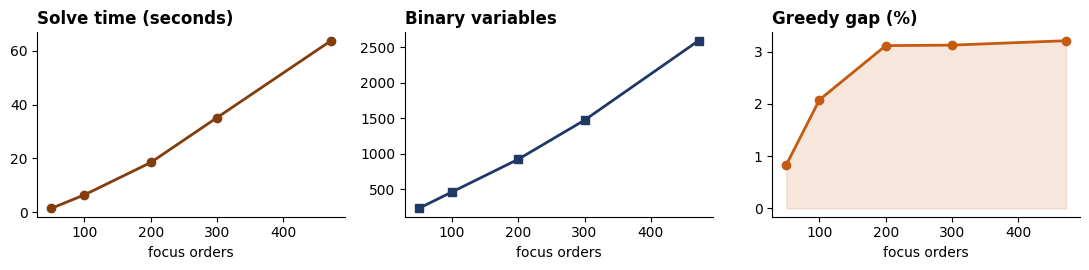

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(11, 2.8))
ax[0].plot(SWEEP.orders, SWEEP.wall_s, "o-", color="#833c0c", lw=2)
ax[0].set_title("Solve time (seconds)", loc="left", fontweight="bold")
ax[1].plot(SWEEP.orders, SWEEP.binaries, "s-", color="#1f3864", lw=2)
ax[1].set_title("Binary variables", loc="left", fontweight="bold")
ax[2].plot(SWEEP.orders, SWEEP.gap_pct, "o-", color="#c55a11", lw=2)
ax[2].fill_between(SWEEP.orders, 0, SWEEP.gap_pct, color="#c55a11", alpha=0.15)
ax[2].set_title("Greedy gap (%)", loc="left", fontweight="bold")
for a in ax:
    a.set_xlabel("focus orders"); a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Why most moves are not possible

From the greedy rejection log. The blocks are business rules, not the warehouse.

                       count  share
reason                             
5% fill gate            1682  46.0%
SKU not stocked there   1457  39.8%
no feasible DC           423  11.6%
100-case floor            37   1.0%
ship date too late        24   0.7%
no dock slot              17   0.5%
no pick capacity          11   0.3%
no gain in objective       8   0.2%


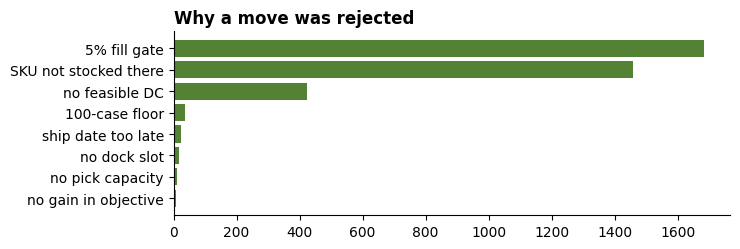


Docks and picking together block 28 of 3,659 candidates.


In [8]:
REJ = pd.DataFrame([
    ("5% fill gate",        1682), ("SKU not stocked there", 1457),
    ("no feasible DC",       423), ("100-case floor",          37),
    ("ship date too late",    24), ("no dock slot",            17),
    ("no pick capacity",      11), ("no gain in objective",     8),
], columns=["reason", "count"]).set_index("reason")
REJ["share"] = (REJ["count"] / REJ["count"].sum()).map(lambda v: f"{v*100:.1f}%")
print(REJ.to_string())

fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.barh(REJ.index[::-1], REJ["count"][::-1], color="#548235")
ax.set_title("Why a move was rejected", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print()
print("Docks and picking together block", int(REJ['count'][['no dock slot','no pick capacity']].sum()),
      "of", f"{REJ['count'].sum():,}", "candidates.")

## 6. The quantum results

Three separate pieces of work, so they are reported separately rather than merged.

### 6.1 Small instance, checked against every possible answer

3 orders and 3 DCs is 9 variables and only 27 valid combinations, so we listed all of them. This is
the check that the QUBO encoding is right before scaling it up.

In [9]:
SMALL = pd.DataFrame([
    dict(method="Leave everything alone",       objective=721_191.3, fill=82.97, moves=0),
    dict(method="Greedy best DC",               objective=760_517.9, fill=87.97, moves=3),
    dict(method="Every combination (true best)", objective=760_517.9, fill=87.97, moves=3),
    dict(method="QUBO ground state (exact)",    objective=760_517.9, fill=87.97, moves=3),
    dict(method="QAOA, best of 5 runs",         objective=760_517.9, fill=87.97, moves=3),
    dict(method="QAOA, mean of 5 runs",         objective=760_341.3, fill=87.97, moves=3),
])
print(SMALL.round(1).to_string(index=False))
print()
print("Ranking the 27 valid answers by QUBO energy gives the same order as ranking them by")
print("money. So the encoding is faithful, not just lucky.")
print("Across 5 QAOA runs: mean $760,341, spread 0.046%, 4 of 5 exactly best, 5 of 5 beat")
print("leaving everything alone. No repair was needed on any run.")

                       method  objective  fill  moves
       Leave everything alone   721191.3  83.0      0
               Greedy best DC   760517.9  88.0      3
Every combination (true best)   760517.9  88.0      3
    QUBO ground state (exact)   760517.9  88.0      3
         QAOA, best of 5 runs   760517.9  88.0      3
         QAOA, mean of 5 runs   760341.3  88.0      3

Ranking the 27 valid answers by QUBO energy gives the same order as ranking them by
money. So the encoding is faithful, not just lucky.
Across 5 QAOA runs: mean $760,341, spread 0.046%, 4 of 5 exactly best, 5 of 5 beat
leaving everything alone. No repair was needed on any run.


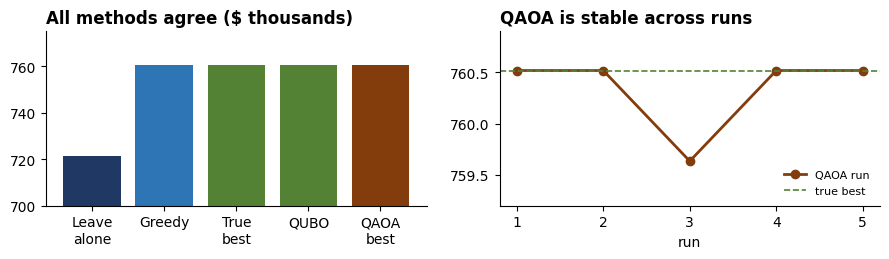

In [10]:
runs = np.arange(1, 6)
qobj = np.array([760_517.9, 760_517.9, 759_634.9, 760_517.9, 760_517.9])
fig, ax = plt.subplots(1, 2, figsize=(9, 2.7))
ax[0].bar(["Leave\nalone", "Greedy", "True\nbest", "QUBO", "QAOA\nbest"],
          SMALL.objective[[0, 1, 2, 3, 4]] / 1e3,
          color=["#1f3864", "#2e75b6", "#548235", "#548235", "#833c0c"])
ax[0].set_ylim(700, 775); ax[0].set_title("All methods agree ($ thousands)", loc="left",
                                          fontweight="bold")
ax[1].plot(runs, qobj / 1e3, "o-", color="#833c0c", lw=2, label="QAOA run")
ax[1].axhline(760.5179, ls="--", color="#548235", lw=1.2, label="true best")
ax[1].set_ylim(759.2, 760.9); ax[1].set_xticks(runs); ax[1].set_xlabel("run")
ax[1].set_title("QAOA is stable across runs", loc="left", fontweight="bold")
ax[1].legend(fontsize=8, frameon=False, loc="lower right")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 6.2 The batched run

Capacity is folded into the objective as a penalty term, so the encoding needs **no slack
variables**. Qubits then equal orders times candidate DCs. A batch of 6 orders and 3 DCs is 18
qubits, with 18 linear and 63 quadratic terms.

The 90 highest-value orders are split into 15 batches of 3 to 6 orders. Batch size stays between 9
and 18 qubits however many orders there are in total.

In [11]:
QUANTUM = pd.DataFrame([
    dict(method="Leave everything alone", objective=13_612_065, fill=88.60, moves=0, violations=0),
    dict(method="Greedy on the same 75",  objective=14_970_736, fill=97.27, moves=75, violations=0),
    dict(method="Quantum + 2-opt repair", objective=14_970_736, fill=97.27, moves=75, violations=0),
])
q = QUANTUM.copy(); q["objective"] = q["objective"].map(lambda v: f"{v:,.0f}")
q["fill"] = QUANTUM["fill"].map(lambda v: f"{v:.2f}%")
print(q.to_string(index=False))
print()
print(f"Gain over leaving everything alone: ${14_970_736 - 13_612_065:,} (+10.0%)")
print("Total quantum solve time: 1.07 seconds across all 15 batches.")
print("Quantum matched or beat the greedy on 15 of 15 batches.")

                method  objective   fill  moves  violations
Leave everything alone 13,612,065 88.60%      0           0
 Greedy on the same 75 14,970,736 97.27%     75           0
Quantum + 2-opt repair 14,970,736 97.27%     75           0

Gain over leaving everything alone: $1,358,671 (+10.0%)
Total quantum solve time: 1.07 seconds across all 15 batches.
Quantum matched or beat the greedy on 15 of 15 batches.


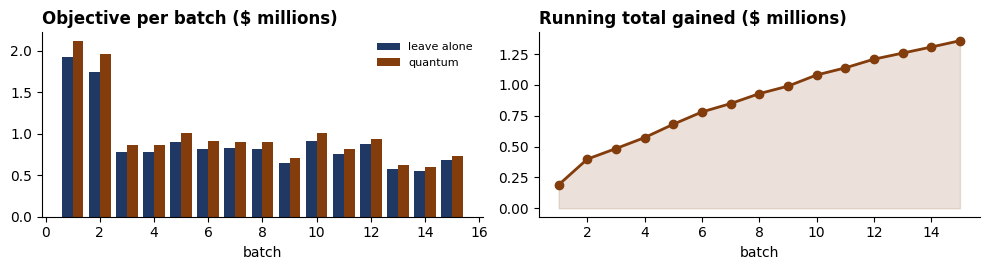

In [12]:
qd = np.array([1_928_200, 1_751_226, 783_691, 777_122, 906_965, 813_861, 833_941, 815_538,
               648_570, 918_804, 755_283, 871_868, 573_044, 554_230, 679_723])
qq = np.array([2_119_248, 1_959_404, 869_247, 865_964, 1_015_163, 913_401, 901_764, 896_210,
               709_231, 1_009_284, 813_069, 942_291, 622_060, 603_579, 730_821])
x = np.arange(1, 16); w = 0.4
fig, ax = plt.subplots(1, 2, figsize=(10, 2.8))
ax[0].bar(x - w/2, qd / 1e6, w, label="leave alone", color="#1f3864")
ax[0].bar(x + w/2, qq / 1e6, w, label="quantum", color="#833c0c")
ax[0].set_title("Objective per batch ($ millions)", loc="left", fontweight="bold")
ax[0].set_xlabel("batch"); ax[0].legend(fontsize=8, frameon=False)
ax[1].plot(x, np.cumsum(qq - qd) / 1e6, "o-", color="#833c0c", lw=2)
ax[1].fill_between(x, 0, np.cumsum(qq - qd) / 1e6, color="#833c0c", alpha=0.15)
ax[1].set_title("Running total gained ($ millions)", loc="left", fontweight="bold")
ax[1].set_xlabel("batch")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 6.3 The hybrid method

A classical step proposes fulfilment options, and QAOA picks among them. On 15 orders in 5 batches,
each choice problem had 6 binary variables and 3 cover rules.

In [13]:
HYBRID = pd.DataFrame([
    dict(batch=i, orders=3, columns=6, binaries=6, status="SUCCESS", gap=0.0)
    for i in range(1, 6)])
print(HYBRID.to_string(index=False))
print()
print("Every batch closed with a gap of exactly zero, in 35.3 seconds of quantum time in total.")
print("This is the closest of our methods to a column-selection model, and it works here")
print("because the choice problem stays small even when the whole problem does not.")

 batch  orders  columns  binaries  status  gap
     1       3        6         6 SUCCESS  0.0
     2       3        6         6 SUCCESS  0.0
     3       3        6         6 SUCCESS  0.0
     4       3        6         6 SUCCESS  0.0
     5       3        6         6 SUCCESS  0.0

Every batch closed with a gap of exactly zero, in 35.3 seconds of quantum time in total.
This is the closest of our methods to a column-selection model, and it works here
because the choice problem stays small even when the whole problem does not.


### 6.4 How to read the quantum result

The quantum solver **matches** the greedy on the batched run. The difference is $0 on every batch.

That is the honest headline. At 18 qubits a batch is small enough that both methods find the same
best answer, so this shows the encoding is **correct**, not that quantum is **faster**.

What it does show is everything that would have to be true before any hardware advantage could be
claimed:

* the QUBO energy order matches the money order on every one of the 27 valid answers,
* the ground state equals the true best answer,
* QAOA reaches that answer in 4 of 5 runs, with a spread of 0.046%,
* the encoding needs no slack variables, so 18 qubits per batch instead of about 54,
* batching keeps the qubit count flat as the number of orders grows.

All of this used exact solvers and noise-free simulation. Real hardware would add gate errors, and
this kind of model is sensitive to them, because a broken rule is only discouraged by a weight and
never forbidden.

## 7. Everything side by side

Two groups, because they cover different sets of orders. The classical methods run on all 472 focus
orders. The quantum methods run on smaller subsets that fit the qubit budget.

In [14]:
ALL = pd.DataFrame([
    dict(group="classical (472 orders)", method="Leave everything alone",
         objective="44,365,994", fill="90.47%", moves=0, runtime="0.21s"),
    dict(group="classical (472 orders)", method="Greedy 2A",
         objective="44,810,604", fill="91.28%", moves=41, runtime="0.40s"),
    dict(group="classical (472 orders)", method="Greedy 2B",
         objective="44,786,479", fill="91.26%", moves=39, runtime="0.42s"),
    dict(group="classical (472 orders)", method="Exact MILP",
         objective="46,295,828", fill="93.28%", moves=66, runtime="63.72s"),
    dict(group="quantum (75 orders)", method="Leave everything alone",
         objective="13,612,065", fill="88.60%", moves=0, runtime="-"),
    dict(group="quantum (75 orders)", method="Greedy on the same 75",
         objective="14,970,736", fill="97.27%", moves=75, runtime="-"),
    dict(group="quantum (75 orders)", method="Quantum, 15 batches",
         objective="14,970,736", fill="97.27%", moves=75, runtime="1.07s"),
    dict(group="quantum (3 orders)", method="QUBO exact ground state",
         objective="760,518", fill="87.97%", moves=3, runtime="0.02s"),
    dict(group="quantum (3 orders)", method="QAOA best of 5",
         objective="760,518", fill="87.97%", moves=3, runtime="1.3s"),
    dict(group="hybrid (15 orders)", method="QAOA choosing options",
         objective="gap 0.00", fill="-", moves=15, runtime="35.3s"),
])
print(ALL.to_string(index=False))

                 group                  method  objective   fill  moves runtime
classical (472 orders)  Leave everything alone 44,365,994 90.47%      0   0.21s
classical (472 orders)               Greedy 2A 44,810,604 91.28%     41   0.40s
classical (472 orders)               Greedy 2B 44,786,479 91.26%     39   0.42s
classical (472 orders)              Exact MILP 46,295,828 93.28%     66  63.72s
   quantum (75 orders)  Leave everything alone 13,612,065 88.60%      0       -
   quantum (75 orders)   Greedy on the same 75 14,970,736 97.27%     75       -
   quantum (75 orders)     Quantum, 15 batches 14,970,736 97.27%     75   1.07s
    quantum (3 orders) QUBO exact ground state    760,518 87.97%      3   0.02s
    quantum (3 orders)          QAOA best of 5    760,518 87.97%      3    1.3s
    hybrid (15 orders)   QAOA choosing options   gap 0.00      -     15   35.3s


## 8. What the results say

* **Both search methods beat leaving orders alone**, and they do it the same way: fill more cases,
  save penalty, pay freight. The objective decides whether the trade was worth it, and it was.
* **The percentage gap looks small because the total is large.** Most of the 472 orders were only
  slightly short. Against the gain that can actually be reached, the greedy leaves about
  three quarters of it behind.
* **The greedy is fast and gets part of the way.** For a planner refreshing recommendations during
  the day that may be the right tool. The exact model is the right tool for setting a target,
  because it is the only one that can say how much is still on the table.
* **The quantum work proves the encoding, not an advantage.** That is a real result, and stating it
  plainly is better than overclaiming.
* **All the methods share the same limits**, and they come from missing data, not from the search:
  no demand forecast, no throughput limit, no holiday calendar.